In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [9]:
merged = pd.read_csv("../data/merged.csv")
print(merged.columns)

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures_mat', 'schoolsup', 'famsup', 'paid_mat', 'activities',
       'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime',
       'goout', 'Dalc', 'Walc', 'health', 'absences_mat', 'G1_mat', 'G2_mat',
       'G3_mat', 'failures_por', 'paid_por', 'absences_por', 'G1_por',
       'G2_por', 'G3_por', 'reussite_mat', 'reussite_por', 'reussite'],
      dtype='object')


In [10]:
# prep

num_cols = ['age', 'Medu', 'Fedu', 'traveltime', 'studytime',
            'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health']
 
# l'élève/études supérieures ?
merged_model = merged[num_cols + ['higher']].dropna()
X_raw = merged_model[num_cols].values
y = (merged_model['higher'] == 'yes').astype(int).values
 
# Normalisation 
scaler = StandardScaler()
X = scaler.fit_transform(X_raw)
 
print(f"{X.shape[0]} individus | classes : {np.bincount(y)} (0=non, 1=oui)")

674 individus | classes : [ 73 601] (0=non, 1=oui)


K optimal : 8 | Accuracy CV : 0.902


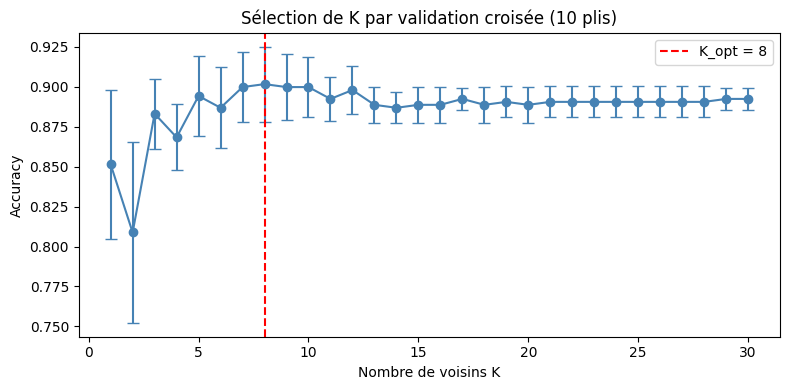

In [11]:
# sep train/test
 
X_dev, X_test, y_dev, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
 
#validation croisée
 
grid = GridSearchCV(
    KNeighborsClassifier(),
    param_grid={"n_neighbors": range(1, 31)},
    scoring="accuracy",
    cv=10
)
grid.fit(X_dev, y_dev)
 
K_opt = grid.best_params_["n_neighbors"]
print(f"K optimal : {K_opt} | Accuracy CV : {grid.best_score_:.3f}")
 
# courbe de sélection
results = grid.cv_results_
ks = np.array(results["param_n_neighbors"].data, dtype=int)
 
plt.figure(figsize=(8, 4))
plt.errorbar(ks, results["mean_test_score"], yerr=results["std_test_score"],
             fmt="o-", capsize=4, color="steelblue")
plt.axvline(K_opt, color="red", linestyle="--", label=f"K_opt = {K_opt}")
plt.title("Sélection de K par validation croisée (10 plis)")
plt.xlabel("Nombre de voisins K")
plt.ylabel("Accuracy")
plt.legend(); plt.tight_layout()
plt.show()

In [12]:

 # estimation final (nn bisaisée)

 
acc_test = np.mean(y_test == grid.best_estimator_.predict(X_test))
print(f"Accuracy finale sur jeu de test : {acc_test:.3f}")

Accuracy finale sur jeu de test : 0.881


In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Remplacer X et y par vos variables cibles (ex: reussite)
# Séparation entraînement / test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalisation
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Instanciation et entraînement du modèle linéaire
lr_linear = LogisticRegression(max_iter=1000, random_state=42)
lr_linear.fit(X_train_scaled, y_train)

# Prédiction et évaluation
y_pred_lin = lr_linear.predict(X_test_scaled)
print("--- Régression Logistique Linéaire ---")
print(f"Accuracy : {accuracy_score(y_test, y_pred_lin):.3f}")

--- Régression Logistique Linéaire ---
Accuracy : 0.889


In [15]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

# Création d'un pipeline : Génération des termes quadratiques -> Régression Logistique
# interaction_only=False (par défaut) génère x_i^2 et x_i * x_j
# include_bias=False car LogisticRegression gère déjà l'intercept
quad_features = PolynomialFeatures(degree=2, include_bias=False)

# Transformation des données
X_train_quad = quad_features.fit_transform(X_train_scaled)
X_test_quad = quad_features.transform(X_test_scaled)

# Instanciation et entraînement du modèle quadratique
lr_quadratic = LogisticRegression(max_iter=2000, random_state=42)
lr_quadratic.fit(X_train_quad, y_train)

# Prédiction et évaluation
y_pred_quad = lr_quadratic.predict(X_test_quad)
print("\n--- Régression Logistique Quadratique ---")
print(f"Accuracy : {accuracy_score(y_test, y_pred_quad):.3f}")


--- Régression Logistique Quadratique ---
Accuracy : 0.852


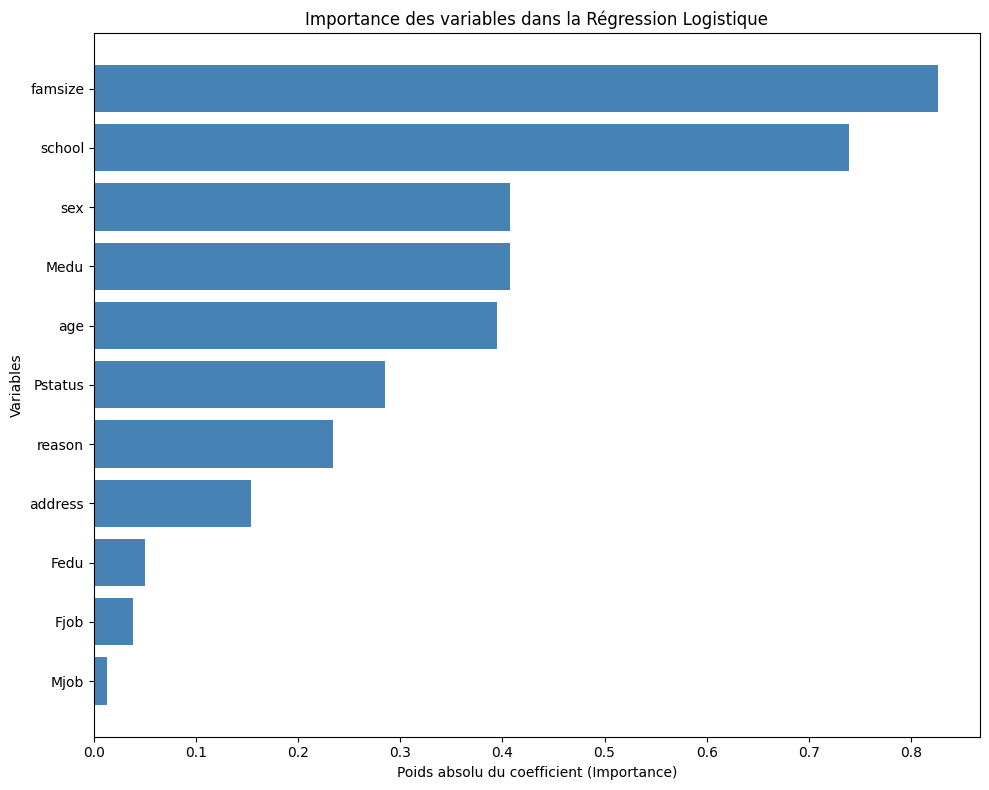

In [26]:
# =========================================================
# CLASSEMENT DES VARIABLES LES PLUS IMPORTANTES (LINÉAIRE)
# =========================================================

# 1. On récupère les coefficients absolus du modèle linéaire
importances = np.abs(lr_linear.coef_[0])

# 2. On récupère le nom de toutes les variables explicatives depuis 'merged'
# On retire simplement la colonne cible (si elle s'appelle 'reussite')
noms_variables = [col for col in merged.columns if col != 'reussite']

# /!\ Sécurité au cas où X_train_scaled contient moins de colonnes que merged (ex: variables catégorielles non encodées)
# On s'assure que la liste des noms fait pile la même taille que le nombre de coefficients
if len(noms_variables) != len(importances):
    noms_variables = noms_variables[:len(importances)]

# 3. Création du DataFrame pour trier et classer
df_importance = pd.DataFrame({
    'Variable': noms_variables,
    'Importance': importances
}).sort_values(by='Importance', ascending=True)

# 4. Affichage du graphique en barres
plt.figure(figsize=(10, 8))
plt.barh(df_importance['Variable'], df_importance['Importance'], color='steelblue')
plt.title("Importance des variables dans la Régression Logistique")
plt.xlabel("Poids absolu du coefficient (Importance)")
plt.ylabel("Variables")
plt.tight_layout()
plt.show()

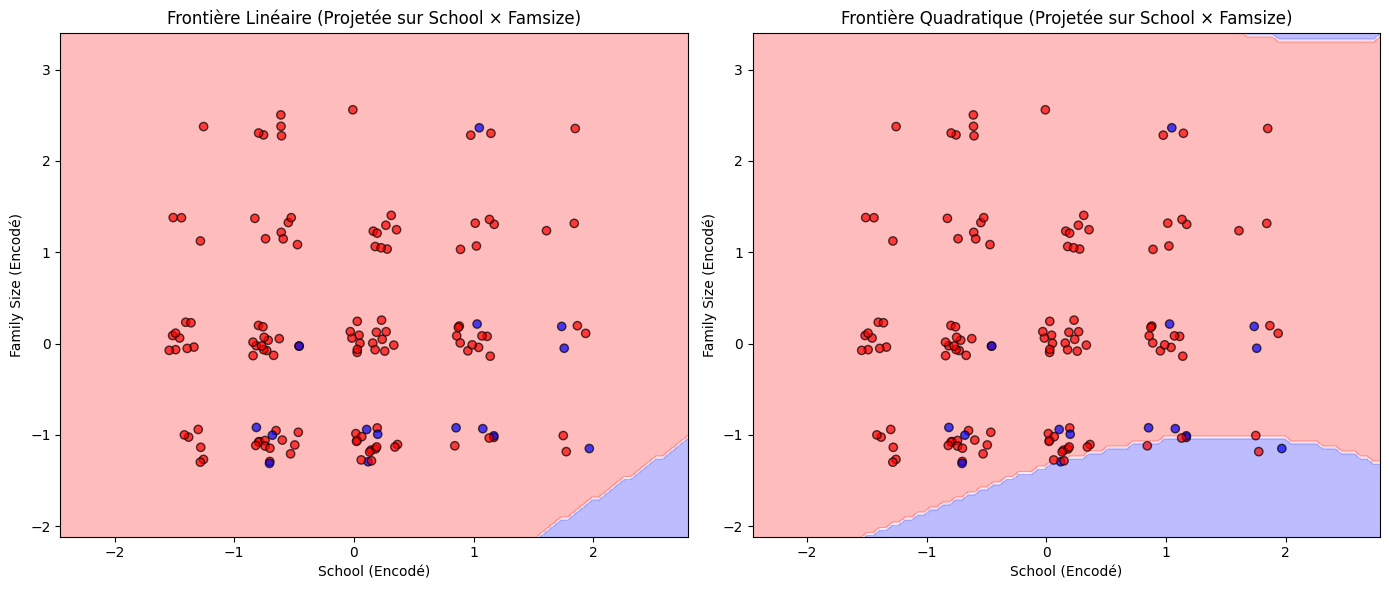

In [28]:
# ==========================================
# CELLULE DU GRAPHIQUE AUTOMATIQUE (famsize vs school)
# ==========================================

# 1. Position des colonnes (à ajuster selon l'index NumPy de votre tableau final)
# Dans le dataframe d'origine : 'school' est à l'index 0, 'famsize' est à l'index 4
index_school = 0   # 'school'
index_famsize = 4  # 'famsize'

# 2. Extraction des paramètres de normalisation
famsize_mean, famsize_std = scaler.mean_[index_famsize], scaler.scale_[index_famsize]
school_mean, school_std = scaler.mean_[index_school], scaler.scale_[index_school]

# 3. Récupération des données depuis les tableaux NumPy (Dénormalisation pour l'affichage)
x_plot = X_test[:, index_school] * school_std + school_mean
y_plot = X_test[:, index_famsize] * famsize_std + famsize_mean

# 4. Création dynamique de la grille de points basée sur le min/max de vos données réelles
school_vals = np.linspace(x_plot.min() - 1, x_plot.max() + 1, 100)
famsize_vals = np.linspace(y_plot.min() - 1, y_plot.max() + 1, 100)
xx_real, yy_real = np.meshgrid(school_vals, famsize_vals)

# 5. Création de la matrice complète normalisée pour les prédictions de la frontière
grid_scaled = np.zeros((10000, X_train_scaled.shape[1]))
grid_scaled[:, index_school] = (xx_real.ravel() - school_mean) / school_std
grid_scaled[:, index_famsize] = (yy_real.ravel() - famsize_mean) / famsize_std

# 6. Calcul des frontières à partir de vos modèles
Z_lin = lr_linear.predict(grid_scaled).reshape(xx_real.shape)
Z_quad = lr_quadratic.predict(quad_features.transform(grid_scaled)).reshape(xx_real.shape)

# 7. Affichage des graphiques avec Jitter (bruit nécessaire pour des variables catégorielles)
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

x_plot_jitter = x_plot + np.random.uniform(-0.2, 0.2, size=len(x_plot))
y_plot_jitter = y_plot + np.random.uniform(-0.2, 0.2, size=len(y_plot))

# Graphique 1 : Frontière Linéaire
ax[0].contourf(xx_real, yy_real, Z_lin, alpha=0.3, cmap='bwr')
ax[0].scatter(x_plot_jitter, y_plot_jitter, c=y_test, edgecolors='k', cmap='bwr', alpha=0.7)
ax[0].set_title("Frontière Linéaire (Projetée sur School × Famsize)")
ax[0].set_xlabel("School (Encodé)")
ax[0].set_ylabel("Family Size (Encodé)")

# Graphique 2 : Frontière Quadratique
ax[1].contourf(xx_real, yy_real, Z_quad, alpha=0.3, cmap='bwr')
ax[1].scatter(x_plot_jitter, y_plot_jitter, c=y_test, edgecolors='k', cmap='bwr', alpha=0.7)
ax[1].set_title("Frontière Quadratique (Projetée sur School × Famsize)")
ax[1].set_xlabel("School (Encodé)")
ax[1].set_ylabel("Family Size (Encodé)")

plt.tight_layout()
plt.show()